# Interactive BdG Spectrum — Kitaev Chain
Real-space eigenvalue snapshot with live parameter sliders.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output

from kitaev_chain import KitaevChain
from utils import setup_style, COLORS

setup_style()
%matplotlib inline

In [2]:
def update(L, mu, t, delta):
    chain     = KitaevChain(L=L, t=t, mu=mu, delta=delta)
    evals     = chain.spectrum()
    abs_evals = np.abs(evals)

    # PH symmetry check: diff[i] = |E_i| - |E_{2L-1-i}|, should be 0 exactly
    half = len(abs_evals) // 2
    diff = abs_evals[:half] - abs_evals[-1:half - 1:-1]

    if abs(mu) < 2 * t:
        phase = 'topological'
    elif abs(mu) > 2 * t:
        phase = 'trivial'
    else:
        phase = 'critical'

    threshold = 0.05 * min(t, delta)
    colors_pt = [COLORS['edge'] if abs(e) < threshold else COLORS[phase]
                 for e in evals]

    # ── Plot 1: full BdG spectrum ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(np.arange(len(evals)), evals, c=colors_pt, s=20, zorder=3)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Eigenvalue index')
    ax.set_ylabel('Energy $E$')
    ax.set_title(
        f'BdG spectrum  —  $L={L}$,  $\\mu={mu:.2f}$,  '
        f'$t={t:.2f}$,  $\\Delta={delta:.2f}$  [{phase}]'
    )
    edge_patch = mpatches.Patch(color=COLORS['edge'], label='near-zero mode')
    bulk_patch = mpatches.Patch(color=COLORS[phase],  label=f'bulk ({phase})')
    ax.legend(handles=[edge_patch, bulk_patch], loc='upper left')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    # ── Plot 2: particle-hole symmetry check ──────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.scatter(np.arange(half), diff, s=20, color='steelblue', zorder=3)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Eigenvalue pair index $i$')
    ax.set_ylabel(r'$|E_i| - |E_{2L-1-i}|$')
    ax.set_title('Particle-hole symmetry check  (should be $\\approx 0$ everywhere)')
    plt.tight_layout()
    plt.show()
    plt.close(fig)


w_L     = widgets.IntSlider(  value=20,  min=4,   max=80,  step=2,    description='L',  continuous_update=False)
w_mu    = widgets.FloatSlider(value=-1., min=-4., max=4.,  step=0.05, description='μ',  continuous_update=False)
w_t     = widgets.FloatSlider(value=1.,  min=0.1, max=3.,  step=0.1,  description='t',  continuous_update=False)
w_delta = widgets.FloatSlider(value=1.,  min=0.,  max=3.,  step=0.1,  description='Δ',  continuous_update=False)

ui  = widgets.VBox([widgets.HBox([w_L, w_mu]), widgets.HBox([w_t, w_delta])])
out = widgets.interactive_output(update, {'L': w_L, 'mu': w_mu, 't': w_t, 'delta': w_delta})
display(ui, out)

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Figure size 1350x600 with 1 Axes>', '…

## Majorana splitting vs system size $L$

Near-zero mode energy $E_0(L) \approx 2(|\mu|/2t)^L$ — exponential decay with $L$.
Use sliders to fix $\mu$, $t$, $\Delta$ and see how fast the edge mode is pinned to zero.

In [3]:
def update_L_scan(mu, t, delta, L_max):
    L_arr  = np.arange(4, L_max + 1, 2)
    E0_arr = np.array([
        np.sort(np.abs(KitaevChain(L=L, t=t, mu=mu, delta=delta).spectrum()))[0]
        for L in L_arr
    ])

    # Analytical prediction (valid for t == delta)
    if abs(mu) < 2 * t and t > 0:
        E0_theory = 2 * t * (abs(mu) / (2 * t)) ** L_arr
    else:
        E0_theory = None

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.semilogy(L_arr, E0_arr, 'o-', color=COLORS['edge'], ms=5, label='numerical $E_0$')
    if E0_theory is not None:
        ax.semilogy(L_arr, E0_theory, '--', color='gray', lw=1.5,
                    label=r'$2t\,(|\mu|/2t)^L$')
    ax.set_xlabel('Chain length $L$')
    ax.set_ylabel('Near-zero mode energy $E_0$')
    ax.set_title(
        f'Majorana splitting vs $L$  —  '
        f'$\\mu={mu:.2f}$,  $t={t:.2f}$,  $\\Delta={delta:.2f}$'
    )
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close(fig)


wL_mu    = widgets.FloatSlider(value=-1., min=-1.99, max=1.99, step=0.05, description='μ',     continuous_update=False)
wL_t     = widgets.FloatSlider(value=1.,  min=0.1,   max=3.,   step=0.1,  description='t',     continuous_update=False)
wL_delta = widgets.FloatSlider(value=1.,  min=0.,    max=3.,   step=0.1,  description='Δ',     continuous_update=False)
wL_Lmax  = widgets.IntSlider(  value=60,  min=10,    max=120,  step=2,    description='L max', continuous_update=False)

ui_L  = widgets.VBox([widgets.HBox([wL_mu, wL_t]), widgets.HBox([wL_delta, wL_Lmax])])
out_L = widgets.interactive_output(update_L_scan, {'mu': wL_mu, 't': wL_t, 'delta': wL_delta, 'L_max': wL_Lmax})
display(ui_L, out_L)

Output()

## Why `np.abs` — the sign-filter artefact

In the BdG formalism, particle-hole symmetry guarantees eigenvalues in exact $\pm E$ pairs **analytically**.
Numerically, `eigvalsh` computes each eigenvalue independently — it does **not** enforce the pairing.
For a Majorana zero mode deep in the topological phase (large $L$), the true energy is

$$E_0 \approx 2t\!\left(\frac{|\mu|}{2t}\right)^L$$

which falls below double-precision machine epsilon ($\approx 2.2\times10^{-16}$) for moderate $L$.
At that point `eigvalsh` can return both members of the near-zero pair as **tiny negative numbers**.
A sign filter `evals[evals >= 0]` then silently drops them, and the "lowest positive eigenvalue"
jumps to the bulk gap — a spurious spike.

The cells below show this concretely with printed values.

In [4]:
# ── Step 1: look at raw eigenvalues near zero for increasing L ────────────────
# mu=-1, t=delta=1  →  E0_theory = (0.5)^L
# double-precision epsilon ≈ 2.2e-16, so E0 drops below it around L ≈ 53

t, mu, delta = 1.0, -1.0, 1.0
EPS = np.finfo(float).eps   # 2.22e-16

print(f"Double-precision machine epsilon: {EPS:.2e}\n")
print(f"{'L':>5}  {'E0 theory':>14}  {'raw evals near 0 (sorted by |E|)':>45}  {'any negative?'}")
print("-" * 90)

for L in [40, 46, 50, 52, 53, 55, 60]:
    evals = np.linalg.eigvalsh(KitaevChain(L=L, t=t, mu=mu, delta=delta).build_hamiltonian())
    # pick the 4 eigenvalues closest to zero
    idx   = np.argsort(np.abs(evals))[:4]
    near  = evals[idx]
    E0_th = 2 * t * (abs(mu) / (2 * t)) ** L
    neg   = "YES ←" if np.any(near < 0) else "no"
    vals  = "  ".join(f"{v:+.3e}" for v in near)
    print(f"{L:>5}  {E0_th:>14.3e}  {vals}  {neg}")

Double-precision machine epsilon: 2.22e-16

    L       E0 theory               raw evals near 0 (sorted by |E|)  any negative?
------------------------------------------------------------------------------------------
   40       1.819e-12  +1.363e-12  -1.365e-12  +1.006e+00  -1.006e+00  YES ←
   46       2.842e-14  +1.978e-14  -2.287e-14  -1.005e+00  +1.005e+00  YES ←
   50       1.776e-15  +1.975e-16  -2.955e-15  +1.004e+00  -1.004e+00  YES ←
   52       4.441e-16  -4.275e-16  -7.127e-15  -1.004e+00  +1.004e+00  YES ←
   53       2.220e-16  +9.945e-18  -2.789e-15  -1.004e+00  +1.004e+00  YES ←
   55       5.551e-17  -1.777e-15  +2.585e-15  -1.003e+00  +1.003e+00  YES ←
   60       1.735e-18  +1.332e-15  +2.716e-15  -1.003e+00  +1.003e+00  YES ←


In [5]:
# ── Step 2: scan mu values and catch every case where sign filter gives wrong answer ──
# "wrong" = sign filter's lowest value differs from abs's lowest value by more
# than a factor of 100 (i.e. it jumped to the bulk gap)

L = 100   # large enough that zero-mode energy ≪ machine epsilon for most mu
t, delta = 1.0, 1.0
mu_scan  = np.linspace(-1.9, 1.9, 400)

print(f"Scanning {len(mu_scan)} mu values with L={L}, t={t}, delta={delta}")
print(f"Flagging cases where sign-filter E0 > 100 × abs E0\n")
print(f"{'mu':>8}  {'E0_theory':>12}  {'E0_abs':>14}  {'E0_sign':>14}  {'ratio':>8}  near-zero raw evals")
print("-" * 100)

spikes_found = 0
for mu in mu_scan:
    evals  = np.linalg.eigvalsh(KitaevChain(L=L, t=t, mu=mu, delta=delta).build_hamiltonian())
    E0_abs = np.sort(np.abs(evals))[0]
    pos    = evals[evals >= 0]
    E0_sign = pos[0] if len(pos) > 0 else np.nan

    if E0_sign > 100 * E0_abs + 1e-30:   # spike detected
        spikes_found += 1
        E0_th  = 2 * t * (abs(mu) / (2 * t)) ** L
        near   = evals[np.argsort(np.abs(evals))[:4]]
        vals   = "  ".join(f"{v:+.3e}" for v in near)
        ratio  = E0_sign / (E0_abs + 1e-300)
        print(f"{mu:>8.4f}  {E0_th:>12.3e}  {E0_abs:>14.3e}  {E0_sign:>14.3e}  {ratio:>8.1f}  {vals}")
        if spikes_found >= 12:
            print("  ... (truncated)")
            break

print(f"\nTotal spikes found: {spikes_found}")

Scanning 400 mu values with L=100, t=1.0, delta=1.0
Flagging cases where sign-filter E0 > 100 × abs E0

      mu     E0_theory          E0_abs         E0_sign     ratio  near-zero raw evals
----------------------------------------------------------------------------------------------------
 -1.3857     2.320e-16       1.728e-15       6.166e-01  356910956319015.6  -1.728e-15  -2.075e-15  +6.166e-01  -6.166e-01
 -1.3762     1.164e-16       9.975e-16       6.261e-01  627621699705921.1  -9.975e-16  -3.269e-15  +6.261e-01  -6.261e-01
 -1.3667     5.812e-17       2.040e-15       6.356e-01  311615513804600.3  -2.040e-15  -3.997e-15  +6.356e-01  -6.356e-01
 -1.2048     1.942e-22       4.441e-16       7.968e-01  1794184467984674.5  -4.441e-16  -1.332e-15  -7.968e-01  +7.968e-01
 -1.1857     3.945e-23       2.273e-15       8.158e-01  358824858978832.9  -2.273e-15  -2.887e-15  +8.158e-01  -8.158e-01
 -1.1667     7.811e-24       1.041e-70       8.348e-01  801915757313413870465317606001000147927808

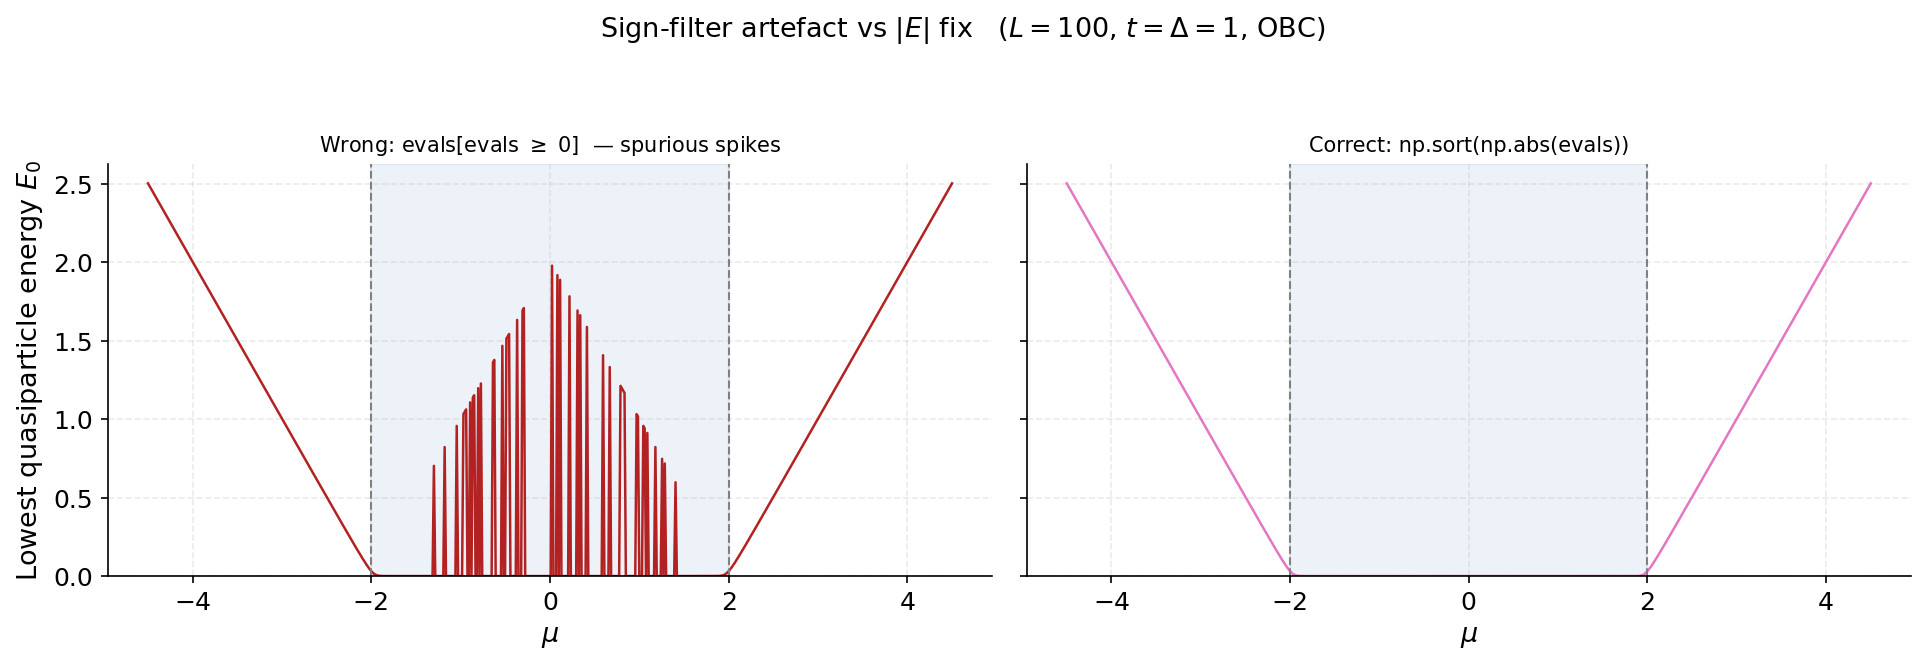

In [6]:
# ── Step 3: visualise — side-by-side comparison of both methods ───────────────
from bdg_bulk import critical_mu

L = 100
t, delta = 1.0, 1.0
mu_scan  = np.linspace(-4.5, 4.5, 600)
mu_c1, mu_c2 = critical_mu(t)

E0_abs  = np.zeros(len(mu_scan))
E0_sign = np.zeros(len(mu_scan))

for i, mu in enumerate(mu_scan):
    evals       = np.linalg.eigvalsh(KitaevChain(L=L, t=t, mu=mu, delta=delta).build_hamiltonian())
    E0_abs[i]   = np.sort(np.abs(evals))[0]
    pos         = evals[evals >= 0]
    E0_sign[i]  = pos[0] if len(pos) > 0 else np.nan

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
labels = [r"Wrong: evals[evals $\geq$ 0]  — spurious spikes", r"Correct: np.sort(np.abs(evals))"]
colors = ['firebrick', COLORS['edge']]

for ax, data, label, col in zip(axes, [E0_sign, E0_abs], labels, colors):
    ax.plot(mu_scan, data, color=col, lw=1.2)
    ax.axvspan(mu_c1, mu_c2, alpha=0.10, color='steelblue', label='topological')
    ax.axvline(mu_c1, color='gray', ls='--', lw=1)
    ax.axvline(mu_c2, color='gray', ls='--', lw=1)
    ax.axhline(0, color='k', lw=0.6, ls=':')
    ax.set_xlabel(r'$\mu$')
    ax.set_title(label, fontsize=10)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel('Lowest quasiparticle energy $E_0$')
fig.suptitle(rf'Sign-filter artefact vs $|E|$ fix   ($L={L}$, $t=\Delta=1$, OBC)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()